In [1]:
from rdkit import Chem # Библиотека (хемоинформатика) для отрисовки 2D структур химических молекул из названия по системе SMILES
from rdkit.Chem import Draw
import pandas as pd
import torch
import random
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms as T
import torch.nn as nn
from torchmetrics.image import StructuralSimilarityIndexMeasure # Для "вознаграждения" и "наказания" модели
import numpy as np
import matplotlib.pyplot as plt
from tqdm.auto import tqdm # Для отслеживания прогресса эпох


In [2]:
df = pd.read_csv('SMILES_Big_Data_Set.csv')

display(df.info())
display(df.head())


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 16087 entries, 0 to 16086
Data columns (total 5 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   SMILES     16087 non-null  object 
 1   pIC50      15037 non-null  float64
 2   mol        16087 non-null  object 
 3   num_atoms  16087 non-null  int64  
 4   logP       16087 non-null  float64
dtypes: float64(2), int64(1), object(2)
memory usage: 628.5+ KB


None

,SMILES,pIC50,mol,num_atoms,logP
0,O=S(=O)(Nc1cccc(-c2cnc3ccccc3n2)c1)c1cccs1,4.26,<rdkit.Chem.rdchem.Mol object at 0x7f59df45bc30>,25,4.1591
1,O=c1cc(-c2nc(-c3ccc(-c4cn(CCP(=O)(O)O)nn4)cc3)...,4.34,<rdkit.Chem.rdchem.Mol object at 0x7f59a320c9e0>,36,3.6743
2,NC(=O)c1ccc2c(c1)nc(C1CCC(O)CC1)n2CCCO,4.53,<rdkit.Chem.rdchem.Mol object at 0x7f59a320cac0>,23,1.5361
3,NCCCn1c(C2CCNCC2)nc2cc(C(N)=O)ccc21,4.56,<rdkit.Chem.rdchem.Mol object at 0x7f59a320cba0>,22,0.9510
4,CNC(=S)Nc1cccc(-c2cnc3ccccc3n2)c1,4.59,<rdkit.Chem.rdchem.Mol object at 0x7f59a320c7b0>,21,3.2130


SMILES этой молекулы: COc1cc2c(c(OC)c1OC)-c1ccc(OC)c(=O)cc1C(NC(C)=O)CC2


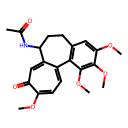

In [3]:
random_smiles = df['SMILES'].sample(n=1).iloc[0] # Выбираем одну случайную строку из колонки SMILES
mol = Chem.MolFromSmiles(random_smiles) # Создаем объект молекулы RDKit
# Отрисовываем:
if mol:
    print(f"SMILES этой молекулы: {random_smiles}")
    img = Draw.MolToImage(mol, size=(128, 128))
    display(img)
else:
    print("Упс, RDKit не смог прочитать этот SMILES")


In [4]:
class MoleculeDataset(Dataset): # Для отрисовки молекул и предачи их в виде матрицы.
    def __init__(self, csv_file, img_size=128):
        self.df = pd.read_csv(csv_file)
        self.img_size = img_size
        # Превращаем картинку в тензор и нормализуем
        self.transform = T.Compose([
            T.ToPILImage(),
            T.Grayscale(), # Делаем ч/б, чтобы модель не отвлекалась на цвета
            T.Resize((img_size, img_size)),
            T.ToTensor(),
        ])

    def __len__(self): # Сколько строк в датасете, чтобы загрузчик знал, когда заканчивать эпоху обучения
        return len(self.df)

    def __getitem__(self, idx):
        smiles = self.df.iloc[idx]['SMILES']
        mol = Chem.MolFromSmiles(smiles)
        
        # Если RDKit не смог прочитать молекулу, возвращаем пустой тензор (или заглушку)
        if mol is None: 
            return torch.zeros((1, self.img_size, self.img_size)) # Пустая черная картинка
            
        # Рисуем молекулу в ч/б
        img = Draw.MolToImage(mol, size=(self.img_size, self.img_size), bw=True)
        img_array = np.array(img)
        
        return self.transform(img_array)

# Создаем загрузчик данных
dataset = MoleculeDataset('SMILES_Big_Data_Set.csv')
dataloader = DataLoader(dataset, batch_size=32, shuffle=True) # Берем записи не все сразу, а по 32 штуки и перемешиваем порядок на каждой эпохе, чтобы модель запоминала не последовательность, а признаки

In [5]:
class MoleculeAutoencoder(nn.Module):
    def __init__(self):
        super().__init__()
        
        # Энкодер: уменьшаем размер, увеличиваем количество признаков
        self.encoder = nn.Sequential(
            nn.Conv2d(1, 32, kernel_size=3, stride=2, padding=1), 
            nn.ReLU(),
            nn.Conv2d(32, 64, kernel_size=3, stride=2, padding=1), 
            nn.ReLU(),
            nn.Conv2d(64, 128, kernel_size=3, stride=2, padding=1), 
            nn.ReLU(),
            nn.Conv2d(128, 256, kernel_size=3, stride=2, padding=1),
            nn.ReLU(),
            nn.Flatten(),
            nn.Linear(256 * 8 * 8, 256) # Скрытое пространство (вектор) из 256 чисел
        )
        
        # Декодер: восстанавливаем обратно
        self.decoder = nn.Sequential(
            nn.Linear(256, 256 * 8 * 8),
            nn.Unflatten(1, (256, 8, 8)),
            nn.ConvTranspose2d(256, 128, kernel_size=3, stride=2, padding=1, output_padding=1), 
            nn.ReLU(),
            nn.ConvTranspose2d(128, 64, kernel_size=3, stride=2, padding=1, output_padding=1), 
            nn.ReLU(),
            nn.ConvTranspose2d(64, 32, kernel_size=3, stride=2, padding=1, output_padding=1), 
            nn.ReLU(),
            nn.ConvTranspose2d(32, 1, kernel_size=3, stride=2, padding=1, output_padding=1),
            nn.Sigmoid() # Чтобы пиксели были от 0 до 1
        )

    def forward(self, x):
        latent = self.encoder(x) # Получаем сжатый код
        return self.decoder(latent) # Восстанавливаем изображение 

model = MoleculeAutoencoder()


In [6]:
# Выбираем девайс: GPU или CPU
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)

print(f"Обучаемся на: {device}")


Обучаемся на: cpu


In [ ]:
ssim_module = StructuralSimilarityIndexMeasure(data_range=1.0).to(device)

def combined_loss(outputs, targets):
    # Weighted MSE: усиливаем внимание на черных линиях (значения близкие к 0)
    # Создаем маску: чем темнее пиксель в оригинале, тем выше вес
    weights = 1.0 + 10.0 * (1.0 - targets) 
    mse_loss = torch.mean(weights * (outputs - targets) ** 2)
    
    # SSIM: отвечает за структурное сходство (чтобы линии не мылились)
    ssim_loss = 1.0 - ssim_module(outputs, targets) # SSIM выдает 1 при идеальном сходстве, поэтому вычитаем из 1
    
    # Смешиваем
    return mse_loss + 0.5 * ssim_loss


In [8]:
def plot_results(model, dataset, num_samples=3):
    model.eval() # Переводим модель в режим оценки
    fig, axes = plt.subplots(2, num_samples, figsize=(12, 8))
    
    with torch.no_grad():
        for i in range(num_samples):
            # Берем случайную молекулу из датасета
            idx = random.randint(0, len(dataset) - 1)
            img = dataset[idx].unsqueeze(0).to(device)
            recon = model(img)
            
            # Оригинал
            axes[0, i].imshow(img.cpu().squeeze(), cmap='gray', interpolation='nearest') # interpolation='nearest' для четкости пикселей
            axes[0, i].set_title(f'Оригинал {i+1}')
            axes[0, i].axis('off')
            
            # Реконструкция
            axes[1, i].imshow(recon.cpu().squeeze(), cmap='gray',interpolation='nearest')
            axes[1, i].set_title(f'Восстановлено {i+1}')
            axes[1, i].axis('off')
            
    plt.tight_layout()
    plt.show()


Эпоха 1:   0%|          | 0/503 [00:00<?, ?it/s]

Эпоха [1/16] завершена. Средний Loss: 0.2647


Эпоха 2:   0%|          | 0/503 [00:00<?, ?it/s]

Эпоха [2/16] завершена. Средний Loss: 0.1360


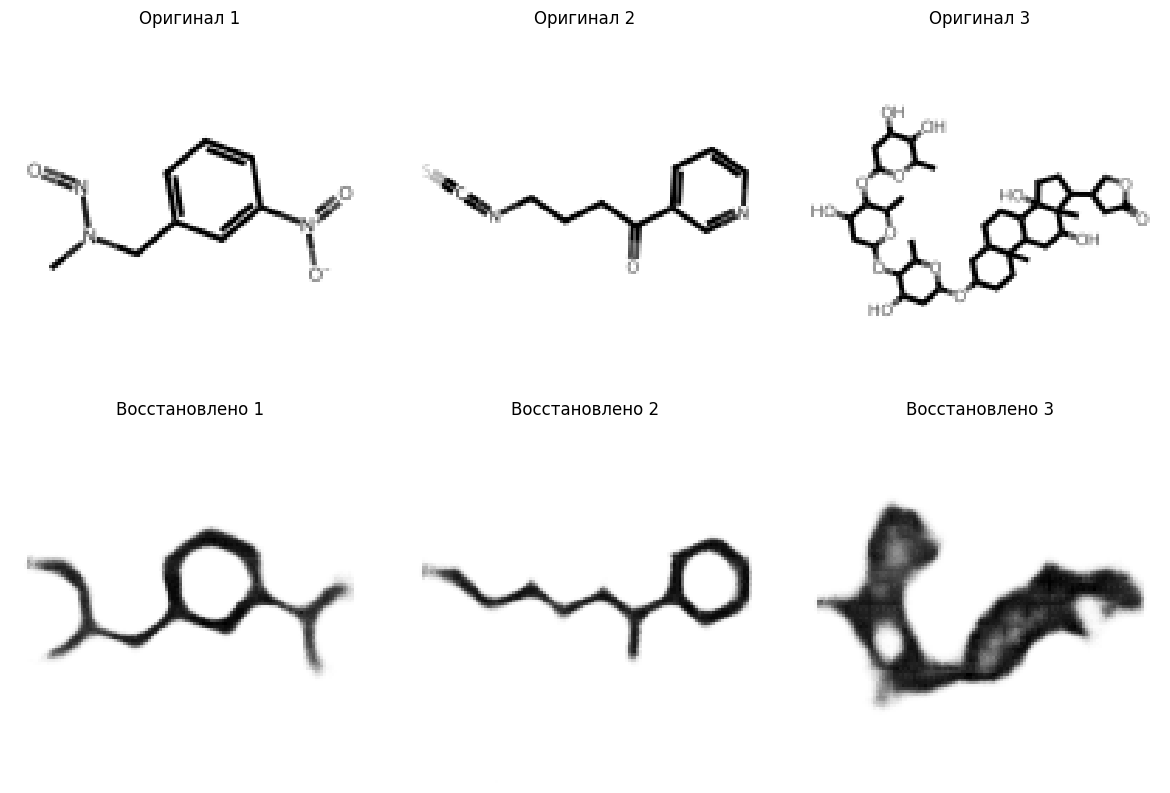

Эпоха 3:   0%|          | 0/503 [00:00<?, ?it/s]

Эпоха [3/16] завершена. Средний Loss: 0.0975


Эпоха 4:   0%|          | 0/503 [00:00<?, ?it/s]

Эпоха [4/16] завершена. Средний Loss: 0.0799


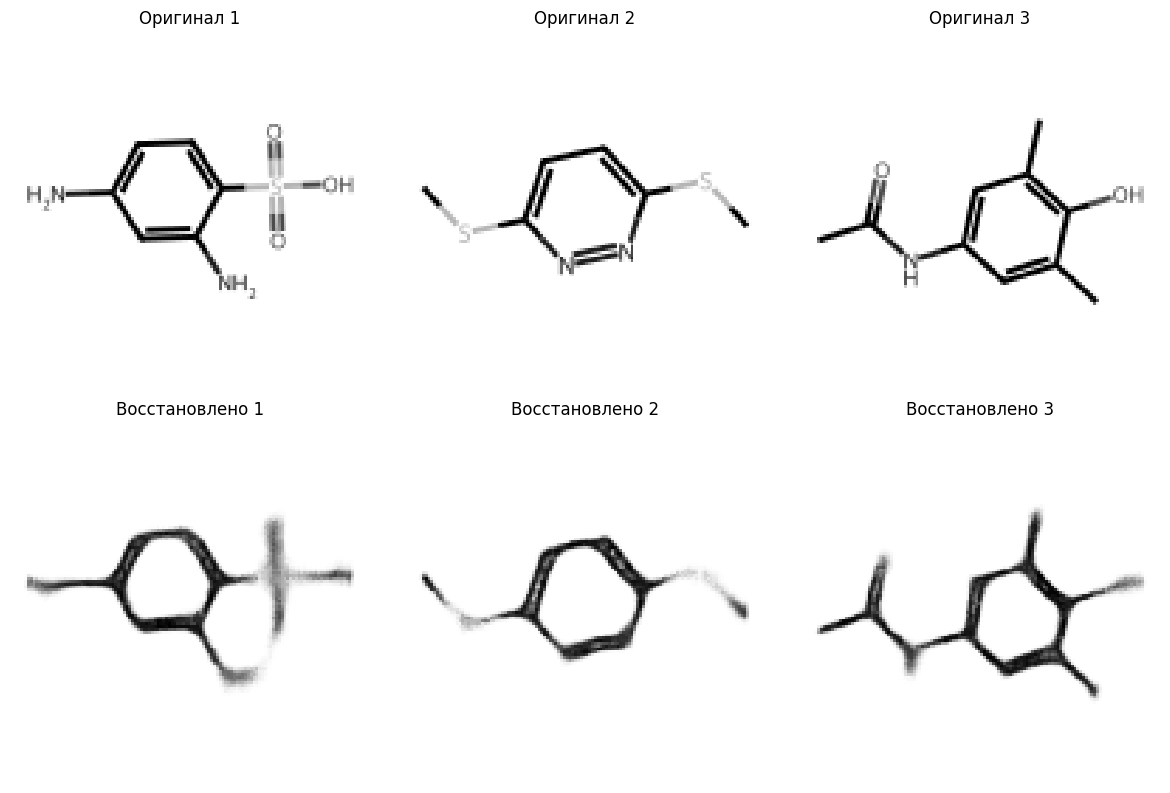

Эпоха 5:   0%|          | 0/503 [00:00<?, ?it/s]

Эпоха [5/16] завершена. Средний Loss: 0.0690


Эпоха 6:   0%|          | 0/503 [00:00<?, ?it/s]

Эпоха [6/16] завершена. Средний Loss: 0.0612


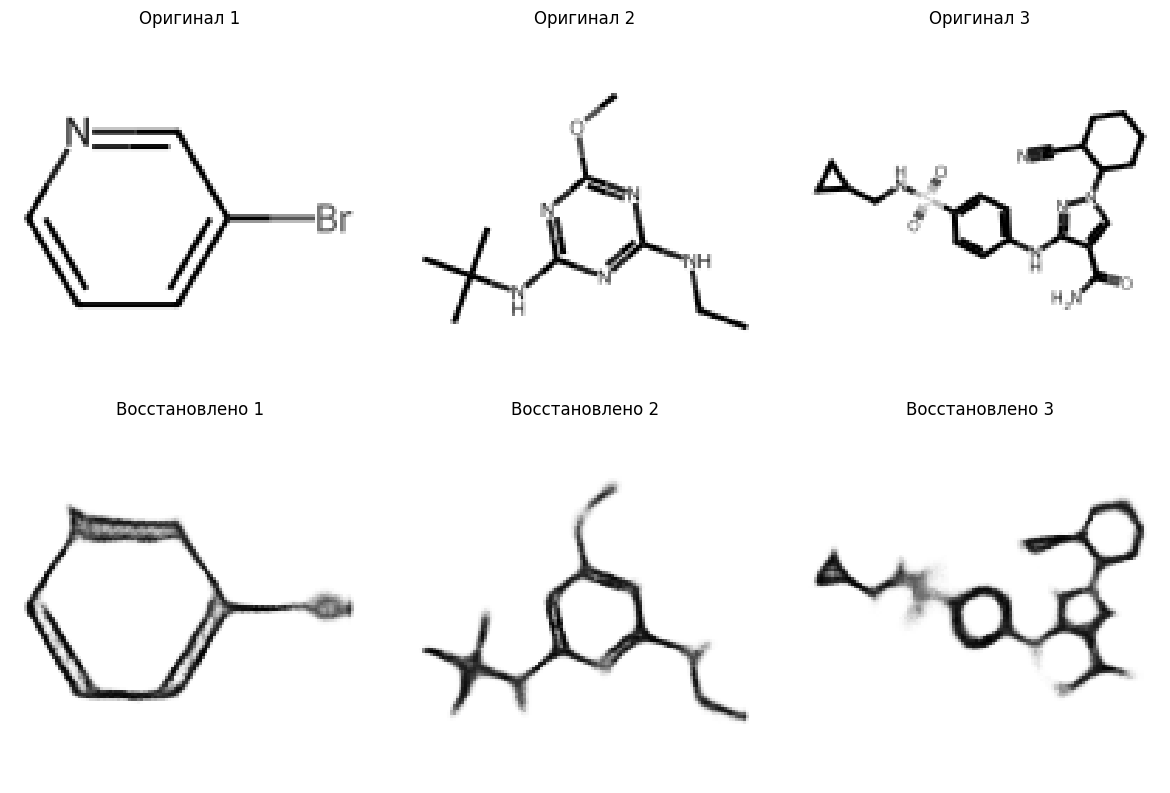

Эпоха 7:   0%|          | 0/503 [00:00<?, ?it/s]

Эпоха [7/16] завершена. Средний Loss: 0.0557


Эпоха 8:   0%|          | 0/503 [00:00<?, ?it/s]

Эпоха [8/16] завершена. Средний Loss: 0.0514


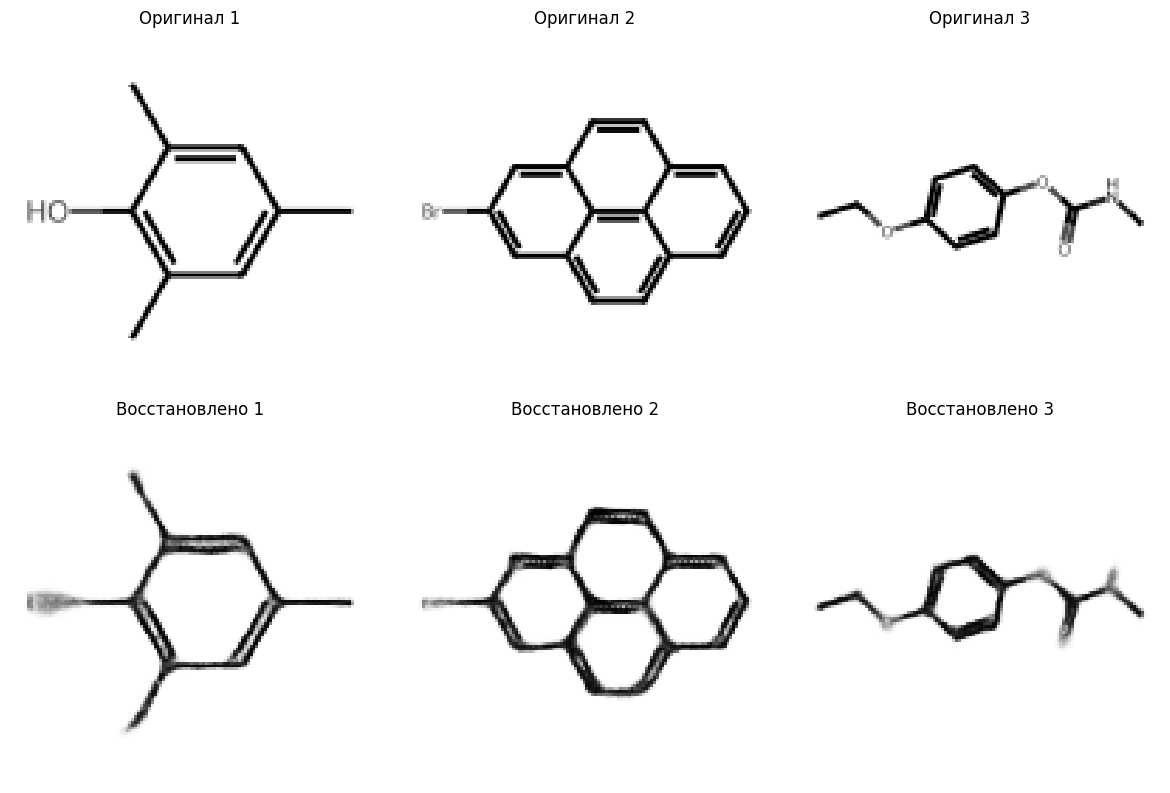

Эпоха 9:   0%|          | 0/503 [00:00<?, ?it/s]

Эпоха [9/16] завершена. Средний Loss: 0.0478


Эпоха 10:   0%|          | 0/503 [00:00<?, ?it/s]

Эпоха [10/16] завершена. Средний Loss: 0.0447


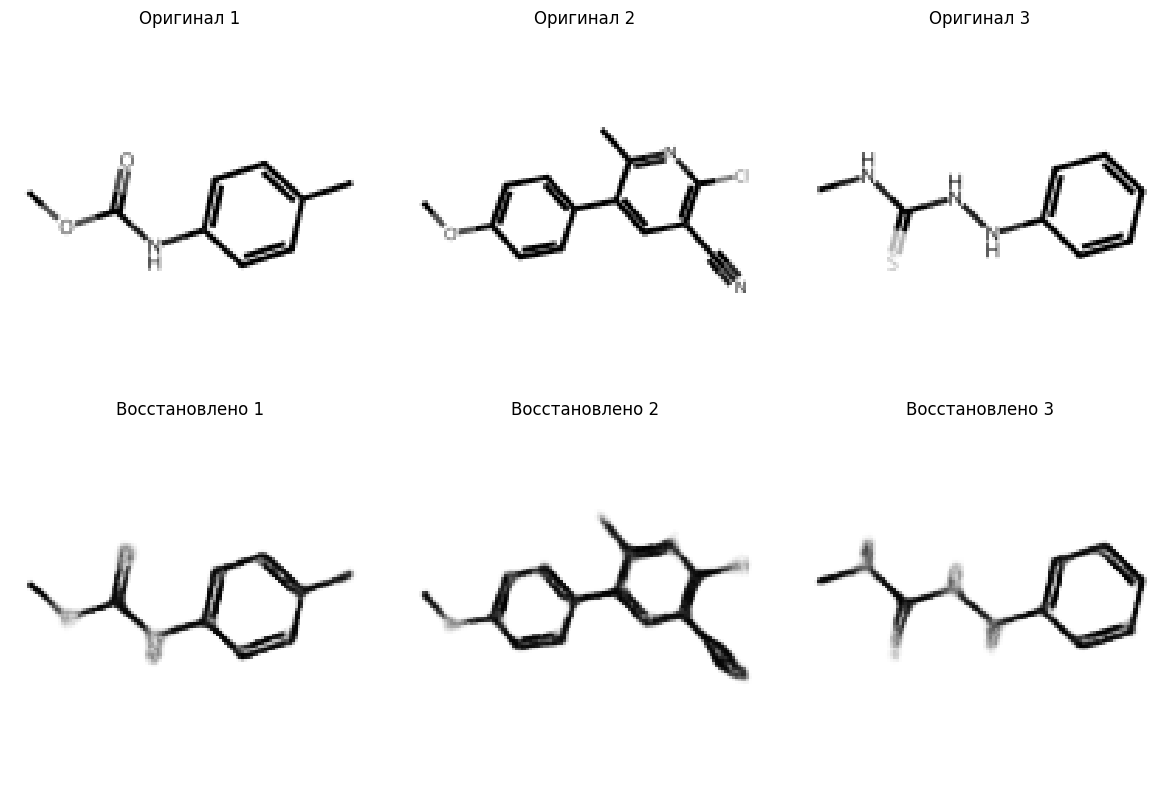

Эпоха 11:   0%|          | 0/503 [00:00<?, ?it/s]

Эпоха [11/16] завершена. Средний Loss: 0.0425


Эпоха 12:   0%|          | 0/503 [00:00<?, ?it/s]

Эпоха [12/16] завершена. Средний Loss: 0.0403


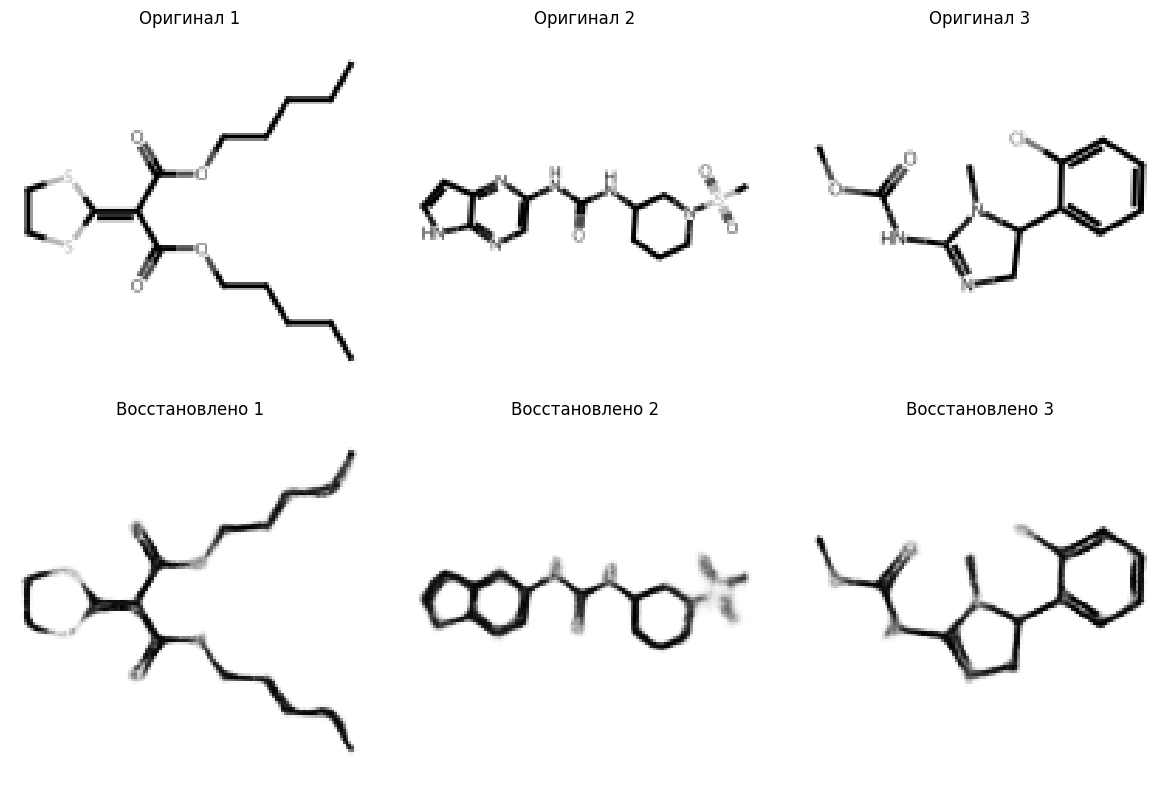

Эпоха 13:   0%|          | 0/503 [00:00<?, ?it/s]

Эпоха [13/16] завершена. Средний Loss: 0.0385


Эпоха 14:   0%|          | 0/503 [00:00<?, ?it/s]

Эпоха [14/16] завершена. Средний Loss: 0.0368


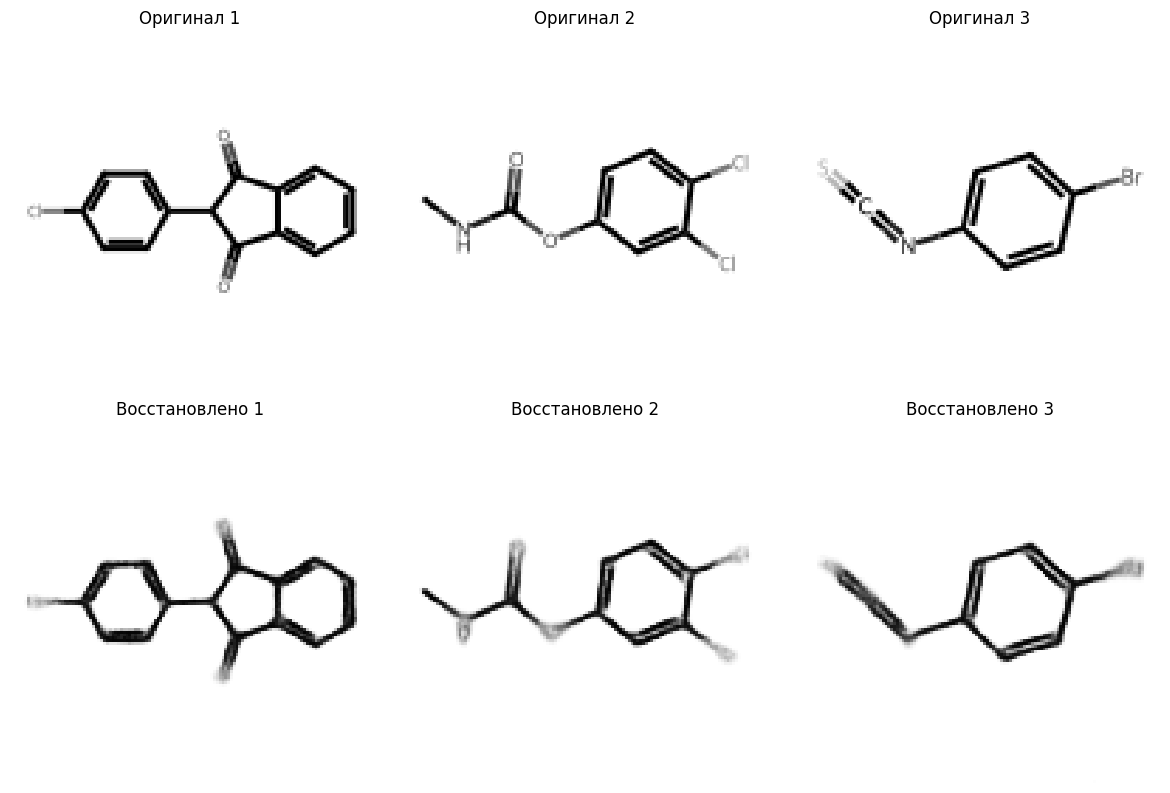

Эпоха 15:   0%|          | 0/503 [00:00<?, ?it/s]

Эпоха [15/16] завершена. Средний Loss: 0.0354


Эпоха 16:   0%|          | 0/503 [00:00<?, ?it/s]

Эпоха [16/16] завершена. Средний Loss: 0.0342


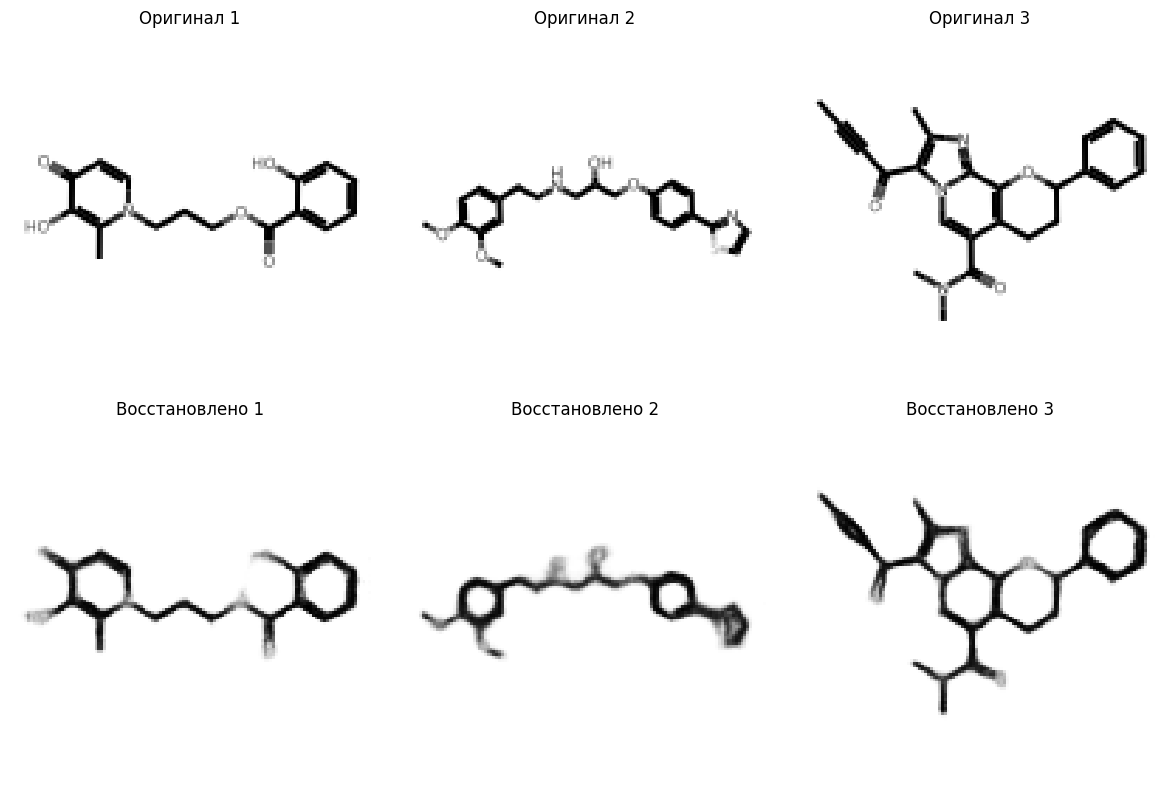

Веса модели сохранены в model_chem_mol.pth


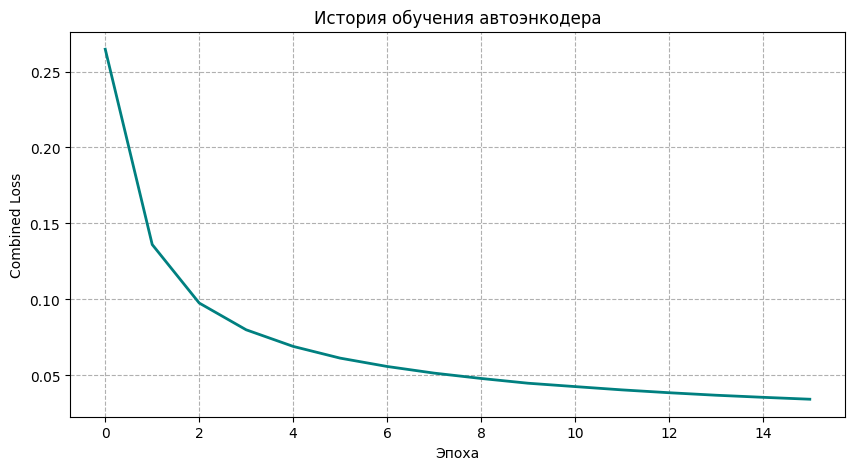

In [ ]:
epochs = 16 
history = [] # Для графика

optimizer = torch.optim.Adam(model.parameters(), lr=0.001) # Оптимизатор

for epoch in range(epochs):
    model.train()
    total_loss = 0
    pbar = tqdm(dataloader, desc=f"Эпоха {epoch+1}")
    
    for batch in pbar:
        batch = batch.to(device)
        optimizer.zero_grad() # Обнуляем градиенты
        
        # Прямой проход
        outputs = model(batch)
        loss = combined_loss(outputs, batch)
        
        # Обратный проход (обучение)
        loss.backward()
        optimizer.step()
        
        total_loss += loss.item()
        pbar.set_postfix({'loss': f"{loss.item():.4f}"})
    
    avg_loss = total_loss / len(dataloader)
    history.append(avg_loss)
    print(f"Эпоха [{epoch+1}/{epochs}] завершена. Средний Loss: {avg_loss:.4f}")
    
    # Каждые 2 эпохи смотрим на картинки
    if (epoch + 1) % 2 == 0:
        plot_results(model, dataset)

# Сохраняем веса
torch.save(model.state_dict(), 'model_chem_mol.pth')
print("Веса модели сохранены в model_chem_mol.pth")

# Строим график
plt.figure(figsize=(10, 5))
plt.plot(history, color='teal', linewidth=2)
plt.title('История обучения автоэнкодера')
plt.xlabel('Эпоха')
plt.ylabel('Combined Loss')
plt.grid(True, ls='--')
plt.show()


In [10]:
# Чекпоинт для того, чтобы сохранить состояние оптимизатора, чтобы при дообучении или использовании модели не было скачка ошибки
checkpoint = {
    'epoch': epoch,
    'model_state_dict': model.state_dict(),
    'optimizer_state_dict': optimizer.state_dict(),
    'loss': avg_loss,
    'history': history # Список лоссов для графика
}
torch.save(checkpoint, 'check_chem_mol.pth')
print("Полный чекпоинт сохранен!")


Полный чекпоинт сохранен!


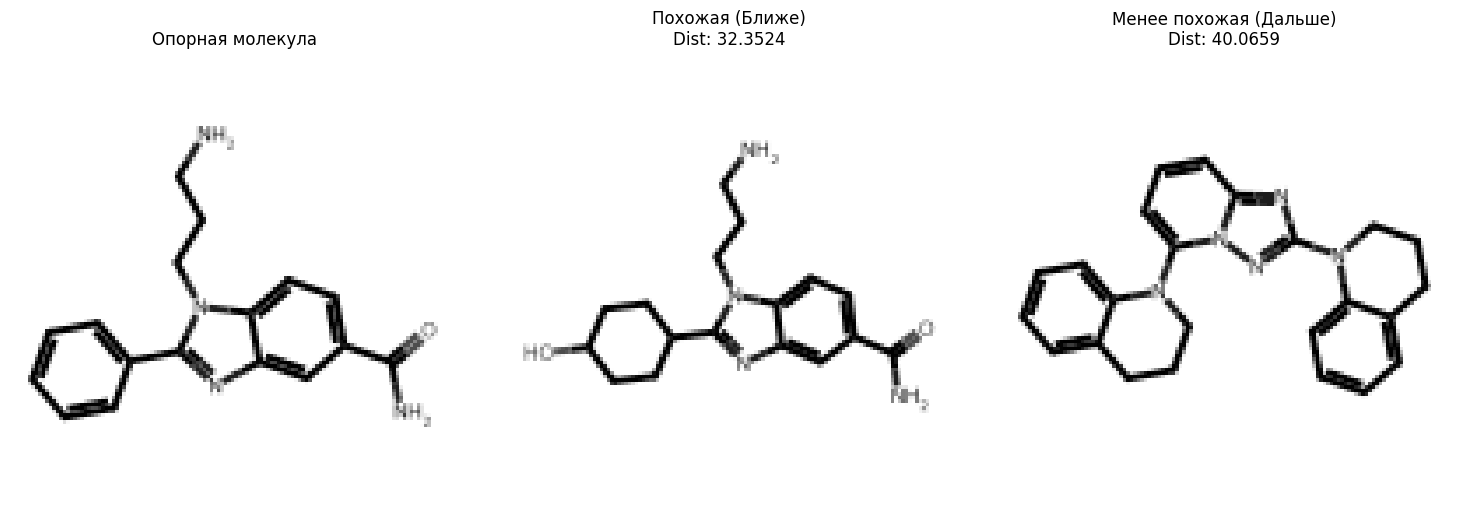

In [30]:
# Смотрим, насколько модель научилась различать и сравнивать изображения молекул
def visualize_similarity(model, dataset, idx_ref, idx_near, idx_far):
    model.eval()
    device = next(model.parameters()).device
    
    indices = [idx_ref, idx_near, idx_far]
    titles = ['Опорная молекула', 'Похожая (Ближе)', 'Менее похожая (Дальше)']
    latents = []
    images = []

    with torch.no_grad():
        for idx in indices:
            img = dataset[idx].unsqueeze(0).to(device)
            latent = model.encoder(img)
            latents.append(latent)
            images.append(dataset[idx].cpu().squeeze())

    # Считаем расстояния от опорной (index 0) до остальных
    dist_near = torch.norm(latents[0] - latents[1]).item()
    dist_far = torch.norm(latents[0] - latents[2]).item()

    # Отрисовка
    fig, axes = plt.subplots(1, 3, figsize=(15, 5))
    for i, ax in enumerate(axes):
        ax.imshow(images[i], cmap='gray')
        if i == 0:
            ax.set_title(titles[i])
        else:
            d = dist_near if i == 1 else dist_far
            ax.set_title(f"{titles[i]}\nDist: {d:.4f}")
        ax.axis('off')
    
    plt.tight_layout()
    plt.show()

# Пример запуска (индексы можно менять, чтобы увидеть разницу)
visualize_similarity(model, dataset, idx_ref=10, idx_near=12, idx_far=50)

Из данного представления видно, что модель уловила основные закономерности научилась "отличать" более похожие молекулы от менее похожих.
Топологически близкие структуры (например, имеющие общие кольцевые системы) располагаются в пространстве в непосредственной близости (Dist: 32,4), даже наличие отличной функциональной группы -ОН в похожей молекуле, которая меняет общий размер изображения, не мешает модели выявлять основное сходство структуры. Структурно отличные молекулы удалены друг от друга на большее расстояние (Dist: 40,1). 

Это доказывает, что 256 признаков в «бутылочном горлышке» (латентном пространстве) являются не случайным набором чисел, а осмысленным цифровым отпечатком (fingerprint) молекулы.

In [31]:
# Чтобы дообучать модель:
# Создаем тело модели и оптимизатор
model = MoleculeAutoencoder().to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

# Загружаем чекпоинт 
checkpoint = torch.load('check_chem_mol.pth', map_location=device)

# Загружаем "память" из файла, раскладываем данные по местам
model.load_state_dict(checkpoint['model_state_dict'])
optimizer.load_state_dict(checkpoint['optimizer_state_dict'])
start_epoch = checkpoint['epoch'] + 1
history = checkpoint['history']

print(f"Готово! Продолжаем с эпохи {start_epoch}")


Готово! Продолжаем с эпохи 16


Дообучение: Эпоха 17:   0%|          | 0/503 [00:00<?, ?it/s]

Эпоха [17/20] завершена. Средний Loss: 0.0330


Дообучение: Эпоха 18:   0%|          | 0/503 [00:00<?, ?it/s]

Эпоха [18/20] завершена. Средний Loss: 0.0322


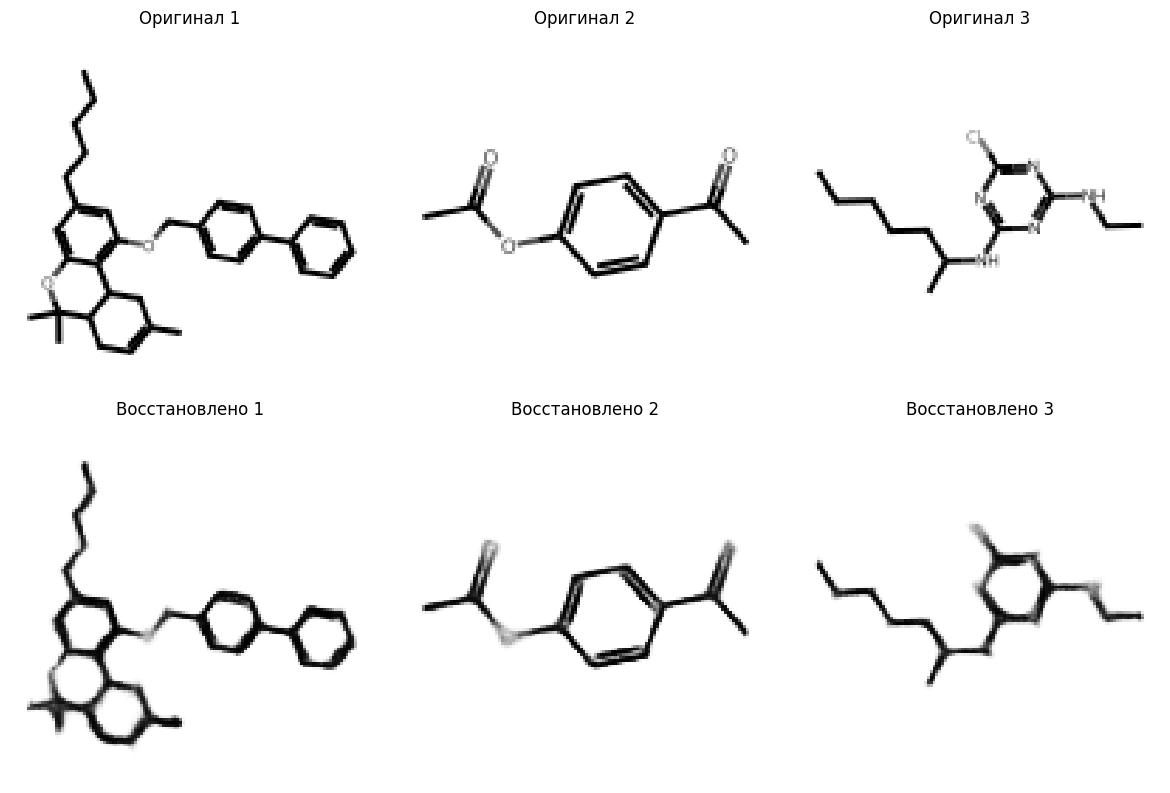

Дообучение: Эпоха 19:   0%|          | 0/503 [00:00<?, ?it/s]

Эпоха [19/20] завершена. Средний Loss: 0.0310


Дообучение: Эпоха 20:   0%|          | 0/503 [00:00<?, ?it/s]

Эпоха [20/20] завершена. Средний Loss: 0.0300


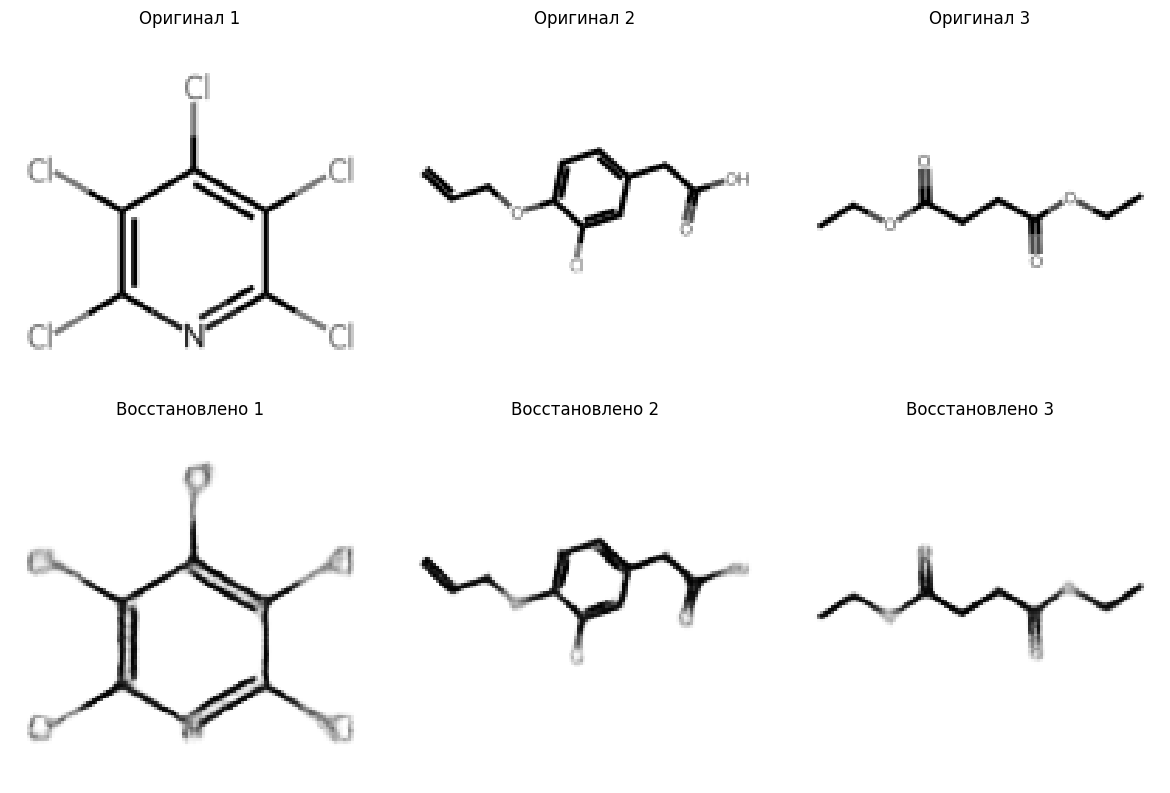

In [32]:
# Указываем, до какой эпохи хотим учить теперь
further_epochs = 20 

for epoch in range(start_epoch, further_epochs):
    model.train()
    total_loss = 0
    pbar = tqdm(dataloader, desc=f"Дообучение: Эпоха {epoch+1}")
    
    for batch in pbar:
        batch = batch.to(device)
        optimizer.zero_grad()
        
        outputs = model(batch)
        loss = combined_loss(outputs, batch) # Новая функция с SSIM
        
        loss.backward()
        optimizer.step()
        
        total_loss += loss.item()
        pbar.set_postfix({'loss': f"{loss.item():.4f}"})
    
    avg_loss = total_loss / len(dataloader)
    history.append(avg_loss) # Продолжаем наполнять тот же список
    print(f"Эпоха [{epoch+1}/{further_epochs}] завершена. Средний Loss: {avg_loss:.4f}")
    
    # Каждые пару эпох сохраняем свежий чекпоинт (на случай сбоя)
    checkpoint = {
        'epoch': epoch,
        'model_state_dict': model.state_dict(),
        'optimizer_state_dict': optimizer.state_dict(),
        'history': history
    }
    torch.save(checkpoint, 'check_chem_mol.pth')
    
    # Каждые 2 эпохи смотрим на картинки
    if (epoch + 1) % 2 == 0:
        plot_results(model, dataset)


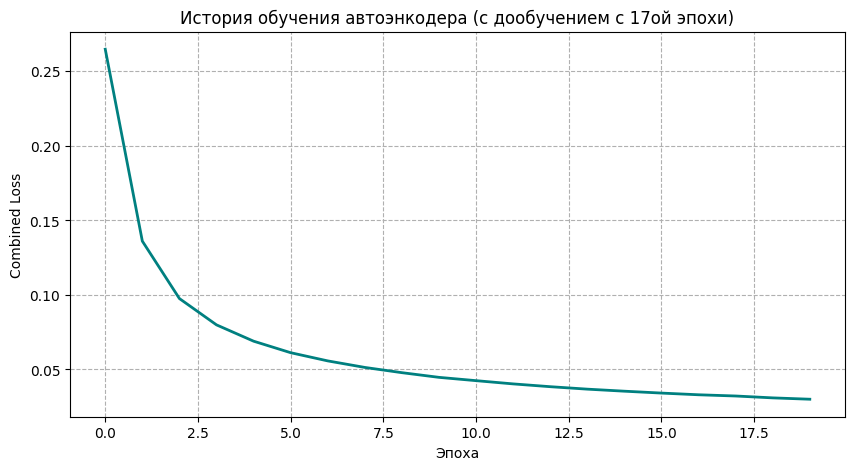

In [34]:
# Обучение наглядно
plt.figure(figsize=(10, 5))
plt.plot(history, color='teal', linewidth=2)
plt.title('История обучения автоэнкодера (с дообучением с 17ой эпохи)')
plt.xlabel('Эпоха')
plt.ylabel('Combined Loss')
plt.grid(True, ls='--')
plt.show()